# HieraticAI — Training

Faster R-CNN R50-FPN trained on pWestcar hieratic signs.

**Design:**
- Zone-specific patches: train/val/test patches contain only their zone's pixels
- 95 active categories (contiguous 0-based)
- Dense overlap (STEP=128) for maximum training views
- Frozen backbone (res1-3) to prevent overfitting
- Heavy augmentation + padded patches for consistent sizes

In [15]:
from google.colab import drive
drive.mount('/content/drive')
import os
PROJECT = '/content/drive/MyDrive/FU/ALP/HieraticAI'
assert os.path.exists(f'{PROJECT}/data/annotations.json'), 'Upload annotations.json'
assert os.path.exists(f'{PROJECT}/data/train_val.png'), 'Upload train_val.png'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
!pip install -q 'git+https://github.com/facebookresearch/detectron2.git'

  Preparing metadata (setup.py) ... done


In [17]:
import json, cv2, numpy as np, torch
from collections import Counter
import detectron2
from detectron2 import model_zoo
from detectron2.config import get_cfg
from detectron2.engine import DefaultTrainer, DefaultPredictor
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import (DatasetCatalog, MetadataCatalog,
                             build_detection_test_loader, DatasetMapper)
from detectron2.data import transforms as T
from detectron2.data.datasets import register_coco_instances
from detectron2.structures import BoxMode
print(f'D2={detectron2.__version__} torch={torch.__version__}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: No GPU. Go to Runtime > Change runtime type > GPU.')

D2=0.6 torch=2.10.0+cu128
GPU: NVIDIA A100-SXM4-40GB


## Load annotations

In [18]:
with open(f'{PROJECT}/data/annotations.json') as f:
    master = json.load(f)
all_anns = master['annotations']
all_cats = master['categories']
IMG_W, IMG_H = master['images'][0]['width'], master['images'][0]['height']
cat_name = {c['id']: c['name'] for c in all_cats}
active_ids = sorted(set(a['category_id'] for a in all_anns))
NC = len(active_ids)
print(f'{IMG_W}x{IMG_H}, {len(all_anns)} signs, {NC} active cats (of {len(all_cats)})')

1190x1684, 605 signs, 95 active cats (of 634)


## Spatial split (Y-band, 30px buffer)
Each annotation assigned to exactly one split by centroid Y.
Buffer zones excluded. Zero annotation leakage.

In [19]:
TRAIN_Y = 1325; BUF = 30; VAL_Y = 1480
tr, va, te, bu = [], [], [], []
for a in all_anns:
    cy = a['bbox'][1] + a['bbox'][3] / 2
    if   cy <= TRAIN_Y:       tr.append(a)
    elif cy <= TRAIN_Y + BUF: bu.append(a)
    elif cy <= VAL_Y:         va.append(a)
    elif cy <= VAL_Y + BUF:   bu.append(a)
    else:                     te.append(a)
n = len(all_anns)
print(f'Train:{len(tr)}({len(tr)/n*100:.0f}%) Val:{len(va)}({len(va)/n*100:.0f}%) '
      f'Test:{len(te)}({len(te)/n*100:.0f}%) Buffer:{len(bu)}')
tr_c = set(a['category_id'] for a in tr)
te_c = set(a['category_id'] for a in te)
print(f'Test cats in train: {len(te_c&tr_c)}/{len(te_c)}')

# Verify zero annotation leakage
tr_ids = set(a['id'] for a in tr)
te_ids = set(a['id'] for a in te)
va_ids = set(a['id'] for a in va)
assert not (tr_ids & te_ids), 'Train-test overlap!'
assert not (tr_ids & va_ids), 'Train-val overlap!'
assert not (va_ids & te_ids), 'Val-test overlap!'
print('Zero annotation leakage verified')

Train:455(75%) Val:67(11%) Test:58(10%) Buffer:25
Test cats in train: 25/26
Zero annotation leakage verified


## Gardiner categories (634 → 95)

In [20]:
o2n = {old: new for new, old in enumerate(active_ids)}
new_cats = [{'id': i, 'name': cat_name[old], 'supercategory': ''}
            for i, old in enumerate(active_ids)]

## Zone-specific patches
Each split gets patches from only its Y-zone.
Train patches never see val/test pixels.
Dense overlap (STEP=128) gives ~80 train patches.
Short patches padded to 512×512 for consistent input size.

In [21]:
PS = 512; STEP = 128; PAD = 30  # padding around annotation extent

def annotation_focused_patches(anns, img_w, img_h, ps, step, pad):
    """Generate patches covering only the area where annotations exist."""
    if not anns:
        return []
    ys = [a['bbox'][1] + a['bbox'][3]/2 for a in anns]
    xs = [a['bbox'][0] + a['bbox'][2]/2 for a in anns]
    y_lo = max(0, int(min(ys)) - pad)
    y_hi = min(img_h, int(max(ys)) + pad)
    x_lo = max(0, int(min(xs)) - pad)
    x_hi = min(img_w, int(max(xs)) + pad)

    patches = []
    if y_hi - y_lo <= ps:
        y_starts = [y_lo]
    else:
        y_starts = list(range(y_lo, y_hi - ps + 1, step))
        if y_starts[-1] + ps < y_hi:
            y_starts.append(y_hi - ps)
    if x_hi - x_lo <= ps:
        x_starts = [x_lo]
    else:
        x_starts = list(range(x_lo, x_hi - ps + 1, step))
        if x_starts[-1] + ps < x_hi:
            x_starts.append(x_hi - ps)
    for py in y_starts:
        for px in x_starts:
            patches.append((px, py))
    return patches

sp = {}
for split, anns in [('train', tr), ('val', va), ('test', te)]:
    sp[split] = annotation_focused_patches(anns, IMG_W, IMG_H, PS, STEP, PAD)
    print(f'  {split}: {len(sp[split])} patches')

print(f'\nTrain patches NEVER see Y > {TRAIN_Y}')

  train: 25 patches
  val: 5 patches
  test: 5 patches

Train patches NEVER see Y > 1325


## Visualize split

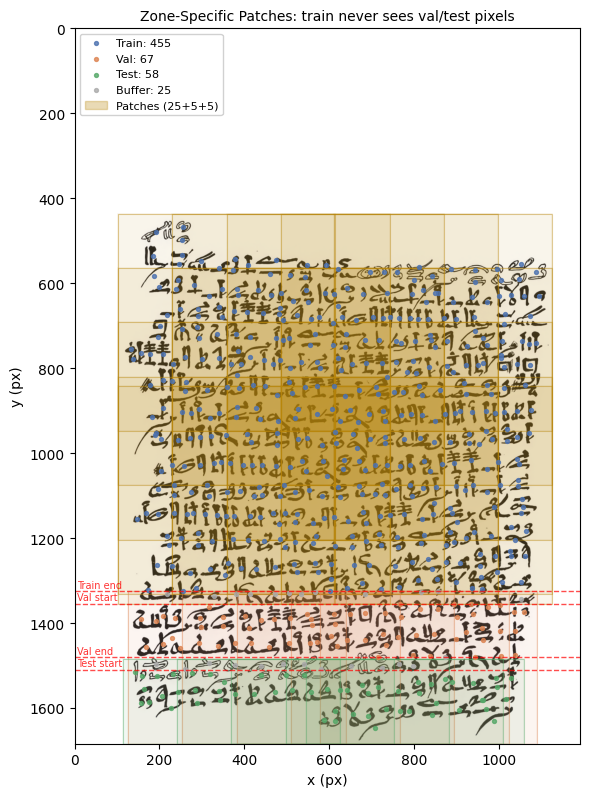

Saved: /content/drive/MyDrive/FU/ALP/HieraticAI/spatial_split_figure.png


In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

img_rgb = cv2.cvtColor(cv2.imread(f'{PROJECT}/data/train_val.png'), cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 1, figsize=(6, 10))
ax.imshow(img_rgb, alpha=0.9)

# Draw zone-specific patches
for split, color in [('train', '#B8860B'), ('val', '#DD8452'), ('test', '#55A868')]:
    for px, py in sp[split]:
        h = min(PS, IMG_H - py)
        rect = mpatches.Rectangle((px, py), PS, h,
            lw=1.2, edgecolor=color, facecolor=color, alpha=0.08)
        ax.add_patch(rect)
        rect2 = mpatches.Rectangle((px, py), PS, h,
            lw=0.8, edgecolor=color, facecolor='none', alpha=0.4)
        ax.add_patch(rect2)

# Color-code annotations by split
for label, split_anns, c in [
    ('Train', tr, '#4C72B0'), ('Val', va, '#DD8452'),
    ('Test', te, '#55A868'), ('Buffer', bu, '#AAAAAA')]:
    if not split_anns: continue
    xs = [a['bbox'][0] + a['bbox'][2]/2 for a in split_anns]
    ys = [a['bbox'][1] + a['bbox'][3]/2 for a in split_anns]
    ax.scatter(xs, ys, c=c, s=8, alpha=0.8, label=f'{label}: {len(split_anns)}')

for y, lbl in [(TRAIN_Y, 'Train end'), (TRAIN_Y+BUF, 'Val start'),
               (VAL_Y, 'Val end'), (VAL_Y+BUF, 'Test start')]:
    ax.axhline(y, color='red', lw=1, ls='--', alpha=0.7)
    ax.text(5, y-8, lbl, fontsize=7, color='red', alpha=0.8)

patch_legend = mpatches.Patch(facecolor='#B8860B', edgecolor='#B8860B',
    alpha=0.3, label=f'Patches ({len(sp["train"])}+{len(sp["val"])}+{len(sp["test"])})')
handles, labels = ax.get_legend_handles_labels()
handles.append(patch_legend)

ax.set_xlim(0, IMG_W); ax.set_ylim(IMG_H, 0)
ax.set_title(f'Zone-Specific Patches: train never sees val/test pixels', fontsize=10)
ax.legend(handles=handles, loc='upper left', fontsize=8, framealpha=0.9)
ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
plt.tight_layout()
plt.savefig(f'{PROJECT}/spatial_split_figure.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {PROJECT}/spatial_split_figure.png')

## Build COCO datasets
Zone-specific patches with padding to 512×512.

In [23]:
img_bgr = cv2.imread(f'{PROJECT}/data/train_val.png')
paths = {}
for split, anns in [('train', tr), ('val', va), ('test', te)]:
    od = f'{PROJECT}/dataset_clean/{split}'; imd = f'{od}/images'
    os.makedirs(imd, exist_ok=True)
    coco = {'images': [], 'annotations': [], 'categories': new_cats}
    aid = 1
    for pi, (px, py) in enumerate(sp[split]):
        # Crop from image, pad to PS×PS if needed
        p = img_bgr[py:min(py+PS, IMG_H), px:min(px+PS, IMG_W)]
        if p.shape[0] < PS or p.shape[1] < PS:
            padded = np.zeros((PS, PS, 3), dtype=np.uint8)
            padded[:p.shape[0], :p.shape[1]] = p
            p = padded
        fn = f'patch_{pi:04d}.png'
        cv2.imwrite(f'{imd}/{fn}', p)
        coco['images'].append({'id': pi+1, 'file_name': fn,
                                'width': PS, 'height': PS})
        for a in anns:
            cx = a['bbox'][0] + a['bbox'][2] / 2
            cy_ = a['bbox'][1] + a['bbox'][3] / 2
            if not (px <= cx < px + PS and py <= cy_ < min(py + PS, IMG_H)):
                continue
            bx = max(0, a['bbox'][0] - px)
            by_ = max(0, a['bbox'][1] - py)
            bw = min(a['bbox'][2], PS - bx)
            bh = min(a['bbox'][3], PS - by_)
            if bw < 5 or bh < 5:
                continue
            ns = []
            for sg in a.get('segmentation', []):
                pl = []
                for i in range(0, len(sg), 2):
                    pl.extend([max(0, min(sg[i] - px, PS)),
                               max(0, min(sg[i+1] - py, PS))])
                ns.append(pl)
            coco['annotations'].append({
                'id': aid, 'image_id': pi + 1,
                'category_id': o2n[a['category_id']],
                'bbox': [bx, by_, bw, bh],
                'segmentation': ns, 'area': bw * bh, 'iscrowd': 0})
            aid += 1
    ap = f'{od}/annotations.json'
    with open(ap, 'w') as f:
        json.dump(coco, f)
    nc = len(set(a['category_id'] for a in coco['annotations']))
    print(f'  {split}: {len(coco["images"])} imgs, '
          f'{len(coco["annotations"])} anns, {nc} cats')
    paths[split] = (ap, imd)

  train: 25 imgs, 3741 anns, 90 cats
  val: 5 imgs, 179 anns, 37 cats
  test: 5 imgs, 157 anns, 26 cats


## Register and configure

In [24]:
for s in ['train', 'val', 'test']:
    nm = f'hieratic_{s}'
    if nm in DatasetCatalog:
        DatasetCatalog.remove(nm); MetadataCatalog.remove(nm)
    register_coco_instances(nm, {}, paths[s][0], paths[s][1])
    MetadataCatalog.get(nm).thing_classes = [c['name'] for c in new_cats]
print(f'Registered {NC} classes')

Registered 95 classes


In [25]:
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file('COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml'))
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url('COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml')
cfg.MODEL.ROI_HEADS.NUM_CLASSES = NC
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.3

# Freeze res1 and res2; let res3+ fine-tune on papyrus textures
cfg.MODEL.BACKBONE.FREEZE_AT = 2

cfg.DATASETS.TRAIN = ('hieratic_train',)
cfg.DATASETS.TEST = ('hieratic_val',)
cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.0002
cfg.SOLVER.MAX_ITER = 30000
cfg.SOLVER.LR_SCHEDULER_NAME = 'WarmupCosineLR'
cfg.SOLVER.WARMUP_ITERS = 1000
cfg.SOLVER.WARMUP_FACTOR = 0.001
cfg.SOLVER.CHECKPOINT_PERIOD = 10000
cfg.DATALOADER.SAMPLER_TRAIN = "RepeatFactorTrainingSampler"
cfg.DATALOADER.REPEAT_THRESHOLD = 0.3
cfg.MODEL.ANCHOR_GENERATOR.SIZES = [[16, 32, 64, 128, 256]]
cfg.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS = [[0.5, 1.0, 2.0]]
cfg.INPUT.MIN_SIZE_TRAIN = (400, 480, 512, 560, 640)
cfg.INPUT.MAX_SIZE_TRAIN = 800
cfg.INPUT.MIN_SIZE_TEST = 512
cfg.INPUT.MAX_SIZE_TEST = 800
cfg.MODEL.RPN.PRE_NMS_TOPK_TRAIN = 6000
cfg.MODEL.RPN.POST_NMS_TOPK_TRAIN = 1000
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 256
cfg.TEST.EVAL_PERIOD = 10000
cfg.OUTPUT_DIR = f'{PROJECT}/model'
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
print(f'{NC} classes, {cfg.SOLVER.MAX_ITER} iters, LR={cfg.SOLVER.BASE_LR}, '
      f'FREEZE_AT={cfg.MODEL.BACKBONE.FREEZE_AT}')

95 classes, 30000 iters, LR=0.0002, FREEZE_AT=2


## Train with heavy augmentation

In [26]:
class HTrainer(DefaultTrainer):
    @classmethod
    def build_train_loader(cls, cfg):
        augs = [
            T.ResizeShortestEdge(cfg.INPUT.MIN_SIZE_TRAIN,
                                 cfg.INPUT.MAX_SIZE_TRAIN, 'choice'),
            T.RandomFlip(prob=0.5, horizontal=True),
            T.RandomFlip(prob=0.3, horizontal=False, vertical=True),
            T.RandomRotation(angle=[-15, 15]),
            T.RandomBrightness(0.6, 1.4),
            T.RandomContrast(0.6, 1.4),
            T.RandomSaturation(0.6, 1.4),
            T.RandomExtent(scale_range=(0.7, 1.3), shift_range=(0.2, 0.2)),
        ]
        return detectron2.data.build_detection_train_loader(
            cfg, mapper=DatasetMapper(cfg, is_train=True, augmentations=augs))
    @classmethod
    def build_evaluator(cls, cfg, dataset_name, output_folder=None):
        return COCOEvaluator(dataset_name,
                             output_dir=output_folder or f'{cfg.OUTPUT_DIR}/eval')

trainer = HTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()
print('Training complete')

[05/19 18:57:55 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

proposal_generator.rpn_head.anchor_deltas.{bias, weight}
proposal_generator.rpn_head.objectness_logits.{bias, weight}
roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}


[05/19 18:57:56 d2.engine.train_loop]: Starting training from iteration 0


/usr/local/lib/python3.12/dist-packages/fvcore/transforms/transform.py:434: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  tensor = torch.from_numpy(np.ascontiguousarray(img))
/usr/local/lib/python3.12/dist-packages/fvcore/transforms/transform.py:434: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at 

[05/19 18:57:59 d2.utils.events]:  eta: 1:08:40  iter: 19  total_loss: 5.771  loss_cls: 4.443  loss_box_reg: 0.2475  loss_rpn_cls: 0.6993  loss_rpn_loc: 0.4115    time: 0.1398  last_time: 0.1283  data_time: 0.0191  last_data_time: 0.0042   lr: 3.9858e-06  max_mem: 6674M
[05/19 18:58:01 d2.utils.events]:  eta: 0:59:54  iter: 39  total_loss: 5.554  loss_cls: 4.188  loss_box_reg: 0.279  loss_rpn_cls: 0.7032  loss_rpn_loc: 0.4122    time: 0.1274  last_time: 0.1170  data_time: 0.0046  last_data_time: 0.0047   lr: 7.9708e-06  max_mem: 6674M
[05/19 18:58:03 d2.utils.events]:  eta: 0:58:13  iter: 59  total_loss: 4.839  loss_cls: 3.508  loss_box_reg: 0.3077  loss_rpn_cls: 0.6936  loss_rpn_loc: 0.3838    time: 0.1241  last_time: 0.1179  data_time: 0.0046  last_data_time: 0.0045   lr: 1.1956e-05  max_mem: 6674M
[05/19 18:58:06 d2.utils.events]:  eta: 0:58:46  iter: 79  total_loss: 3.505  loss_cls: 2.173  loss_box_reg: 0.3912  loss_rpn_cls: 0.6808  loss_rpn_loc: 0.3777    time: 0.1232  last_time: 

## Evaluate on test set

In [27]:
from detectron2.modeling import build_model
from detectron2.checkpoint import DetectionCheckpointer
from detectron2.modeling import GeneralizedRCNNWithTTA


cfg.MODEL.WEIGHTS = f'{cfg.OUTPUT_DIR}/model_final.pth'
cfg.DATASETS.TEST = ('hieratic_test',)
ev = COCOEvaluator('hieratic_test', output_dir=f'{cfg.OUTPUT_DIR}/eval_test')
res = inference_on_dataset(DefaultPredictor(cfg).model,
                           build_detection_test_loader(cfg, 'hieratic_test'), ev)

b = res['bbox']

# Build model and load weights
model = build_model(cfg)
model.eval()
checkpointer = DetectionCheckpointer(model)
checkpointer.load(os.path.join(cfg.OUTPUT_DIR, "model_final.pth"))

# TTA wrapper
tta_cfg = cfg.clone()
tta_cfg.TEST.AUG.ENABLED = True
tta_cfg.TEST.AUG.MIN_SIZES = (400, 512, 600)
tta_cfg.TEST.AUG.MAX_SIZE = 800
tta_cfg.TEST.AUG.FLIP = True
tta_model = GeneralizedRCNNWithTTA(tta_cfg, model)

# Evaluate on test
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader

evaluator = COCOEvaluator("hieratic_test", output_dir=os.path.join(cfg.OUTPUT_DIR, "eval_test_tta"))
test_loader = build_detection_test_loader(cfg, "hieratic_test")
results = inference_on_dataset(tta_model, test_loader, evaluator)
print(f"\n{'='*50}")
print(f"TTA RESULTS")
print(f"{'='*50}")
print(f"mAP (0.50:0.95): {results['bbox']['AP']:.1f}%")
print(f"AP50:             {results['bbox']['AP50']:.1f}%")
print(f"AP75:             {results['bbox']['AP75']:.1f}%")

[05/19 19:57:03 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/drive/MyDrive/FU/ALP/HieraticAI/model/model_final.pth ...
WARNING [05/19 19:57:04 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[05/19 19:57:04 d2.data.datasets.coco]: Loaded 5 images in COCO format from /content/drive/MyDrive/FU/ALP/HieraticAI/dataset_clean/test/annotations.json
[05/19 19:57:04 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(512, 512), max_size=800, sample_style='choice')]
[05/19 19:57:04 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[05/19 19:57:04 d2.data.common]: Serializing 5 elements to byte tensors and concatenating them all ...
[05/19 19:57:04 d2.data.common]: Serialized dataset takes 0.03 MiB
[05/19 19:57:04 d2.evaluation.evaluator]: Start inference on 5 batches
[05/19 19:57:04

## Save results

In [28]:
summary = {
    'split': {'train': len(tr), 'val': len(va), 'test': len(te),
              'buffer': len(bu), 'num_classes': NC,
              'train_y': TRAIN_Y, 'val_y': VAL_Y, 'buffer_px': BUF},
    'patches': {'train': len(sp['train']), 'val': len(sp['val']),
                'test': len(sp['test']), 'size': PS, 'step': STEP},
    'bbox': {k: round(v, 2) for k, v in b.items()},
}
with open(f'{cfg.OUTPUT_DIR}/results_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(f'Saved: {cfg.OUTPUT_DIR}/results_summary.json')
print(f'\nResults:')
print(f'  Split: train {len(tr)} / val {len(va)} / test {len(te)} (buffer {len(bu)})')
print(f'  Categories: {NC} active')
print(f'  mAP: {b["AP"]:.1f}%')

Saved: /content/drive/MyDrive/FU/ALP/HieraticAI/model/results_summary.json

PAPER UPDATES:
  Split: train 455 / val 67 / test 58 (buffer 25)
  Categories: 95 active
  mAP: 30.9%
